In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
data = pd.read_csv("diabetes.csv")

# Show first 5 rows
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Check dataset shape
data.shape

(768, 9)

In [4]:
# Check data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Check missing values
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


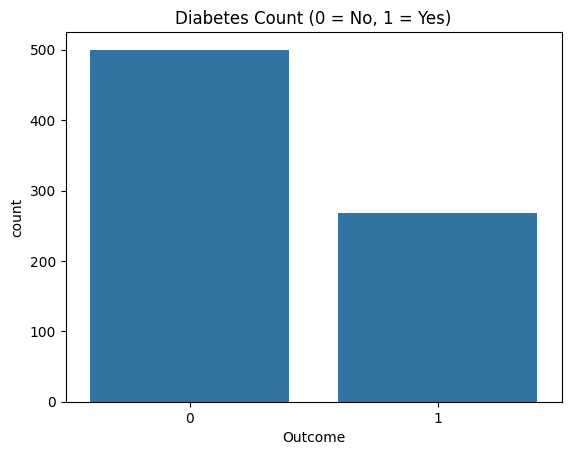

In [6]:
sns.countplot(x='Outcome', data=data)
plt.title("Diabetes Count (0 = No, 1 = Yes)")
plt.show()

In [7]:
# Checking zero values in important columns
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    print(col, (data[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [10]:
#Replace "0" Values with Median
for col in cols:
    data[col] = data[col].replace(0, data[col].median())

In [9]:
# Recheck again if zero values are present or not
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    print(col, (data[col] == 0).sum())

Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0


In [11]:
#Split Features & Target
# Features (X) and Target (y)
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,30.5,33.6,0.627,50
1,1,85,66,29,30.5,26.6,0.351,31
2,8,183,64,23,30.5,23.3,0.672,32
3,1,89,66,23,94.0,28.1,0.167,21
4,0,137,40,35,168.0,43.1,2.288,33


In [12]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [13]:
#test and train split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (614, 8)
Testing data size: (154, 8)


In [14]:
#Feature Scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**LOGISTIC REGRESSION MODEL**

In [15]:
#LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create model
log_model = LogisticRegression()

# Train model
log_model.fit(X_train, y_train)

# Predict on test data
y_pred_log = log_model.predict(X_test)

# Accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", accuracy_log)

Logistic Regression Accuracy: 0.7662337662337663


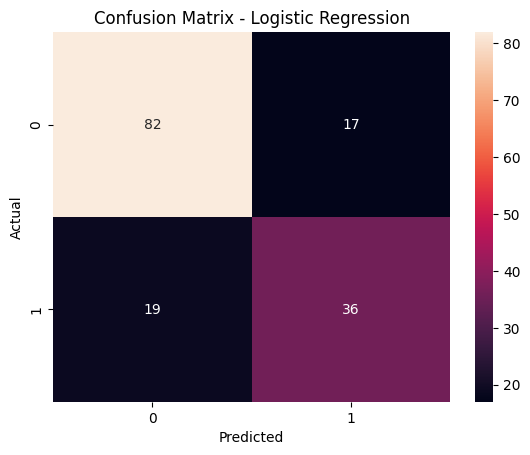

In [16]:
#confusionMatrix
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



**RANDOM FOREST MODEL**

In [18]:
#RandomForestModel
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7662337662337663


In [19]:
# Get feature importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
1,Glucose,0.264943
5,BMI,0.163291
7,Age,0.141010
6,DiabetesPedigreeFunction,0.122428
2,BloodPressure,0.089150
4,Insulin,0.077839
0,Pregnancies,0.074988
3,SkinThickness,0.066351


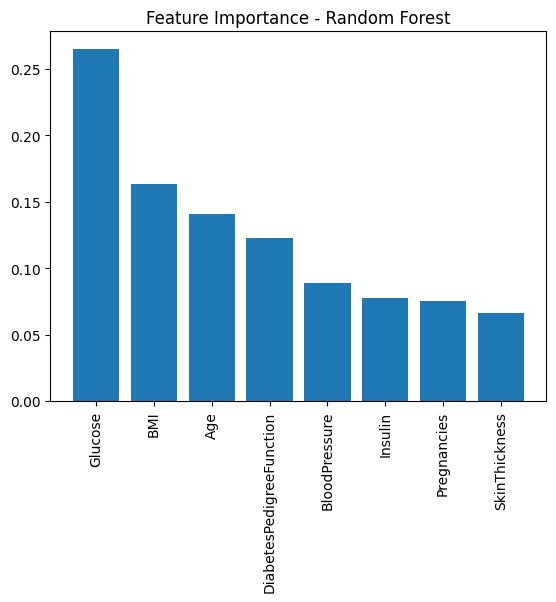

In [20]:
plt.figure()
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importance - Random Forest")
plt.show()

**Some New Time Scenario - Example Below**

In [21]:
# Example new patient data
new_patient = [[6, 148, 72, 35, 0, 33.6, 0.627, 50]]

# Scale it
new_patient_scaled = scaler.transform(new_patient)

# Predict
prediction = rf_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("Patient is likely Diabetic")
else:
    print("Patient is NOT Diabetic")

Patient is likely Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
import joblib

# Save model
joblib.dump(rf_model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']